# Flight Delay Feature Engineering & Feature Store:

This notebook reads the cleaned 2025 flight data from Athena, engineers features for predicting arrival delays stores the features in Amazon SageMaker Feature Store and creates training, validation, test and production datasets.

In [47]:
import time
import boto3
import awswrangler as wr
import pandas as pd
from botocore.exceptions import ClientError

from IPython.display import display

In [3]:
# AWS configuration
region = boto3.Session().region_name or "us-east-1"
account_id = boto3.client("sts").get_caller_identity()["Account"]

role_arn = f"arn:aws:iam::{account_id}:role/LabRole"

# Athena configuration
athena_db = "aai540_group1"
source_table = "clean_flights_full"
athena_s3_output = (
	f"s3://aws-athena-query-results-{account_id}-{region}/"
)

# Shared processed bucket
processed_bucket = "aai-540-group1-flight-data-processed" 
model_ready_prefix = "model-ready"

# Output locations assigned to Denis
engineered_s3_path = (
	f"s3://{processed_bucket}/{model_ready_prefix}/engineered/"
)

train_s3_path = (
	f"s3://{processed_bucket}/{model_ready_prefix}/splits/train/"
)

validation_s3_path = (
	f"s3://{processed_bucket}/{model_ready_prefix}/splits/validation/"
)

test_s3_path = (
	f"s3://{processed_bucket}/{model_ready_prefix}/splits/test/"
)

production_s3_path = (
	f"s3://{processed_bucket}/{model_ready_prefix}/splits/production/"
)

feature_store_s3_path = (
	f"s3://{processed_bucket}/{model_ready_prefix}/feature-store/"
)

print("AWS Account:", account_id)
print("Region:", region)
print("Execution role:", role_arn)
print("Source table:", f"{athena_db}.{source_table}")
print("Output location:", engineered_s3_path)

AWS Account: 697977302576
Region: us-east-1
Execution role: arn:aws:iam::697977302576:role/LabRole
Source table: aai540_group1.clean_flights_full
Output location: s3://aai-540-group1-flight-data-processed/model-ready/engineered/


In [4]:
source_check = wr.athena.read_sql_query(
	f"""
	SELECT
		COUNT(*) AS total_rows,
		COUNT(DISTINCT month) AS months,
		MIN(CAST(month AS INTEGER)) AS first_month,
		MAX(CAST(month AS INTEGER)) AS last_month
	FROM {source_table}
	""",
	database=athena_db,
	s3_output=athena_s3_output
)

display(source_check)

[09/20/26 16:16:37] INFO     Created CTAS table                    ]8;id=14480838;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py\_utils.py]8;;\:]8;id=14480839;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py#928\928]8;;\
                             "aai540_group1"."temp_table_bf0d09975              
                             04c4dbdbee4c449e5585bb5"                           
                    INFO     Initializing a Ray instance            ]8;id=14480846;file:///opt/conda/lib/python3.12/site-packages/awswrangler/distributed/ray/_core.py\_core.py]8;;\:]8;id=14480847;file:///opt/conda/lib/python3.12/site-packages/awswrangler/distributed/ray/_core.py#202\202]8;;\


2026-09-20 16:16:40,218	WARNING services.py:2213 -- WARNING: The object store is using /tmp/ray instead of /dev/shm because /dev/shm has only 408924160 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.68gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-09-20 16:16:46,417	INFO worker.py:2012 -- Started a local Ray instance.
/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


,total_rows,months,first_month,last_month
0,6879484,12,1,12


### Candidate Feature Analysis:

Before engineering the final dataset, candidate features are evaluated for missing values, relationships with the target, redundancy and possible target leakage. Numeric features are examined with a correlation matrix, while categorical features are compared using their observed delay rates.

In [5]:
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set_theme(style="whitegrid")

[09/20/26 16:27:32] INFO     generated new fontManager      ]8;id=14480854;file:///opt/conda/lib/python3.12/site-packages/matplotlib/font_manager.py\font_manager.py]8;;\:]8;id=14480855;file:///opt/conda/lib/python3.12/site-packages/matplotlib/font_manager.py#1639\1639]8;;\


In [14]:
missing_check = wr.athena.read_sql_query(
    f"""
    SELECT
        COUNT(*) AS total_rows,

        ROUND(
            100.0 * COUNT_IF(NULLIF(TRIM(opuniquecarrier), '') IS NULL)
            / COUNT(*), 2
        ) AS airline_missing_pct,

        ROUND(
            100.0 * COUNT_IF(NULLIF(TRIM(origin), '') IS NULL)
            / COUNT(*), 2
        ) AS origin_missing_pct,

        ROUND(
            100.0 * COUNT_IF(NULLIF(TRIM(dest), '') IS NULL)
            / COUNT(*), 2
        ) AS destination_missing_pct,

        ROUND(
            100.0 * COUNT_IF(TRY_CAST(crsdeptime AS DOUBLE) IS NULL)
            / COUNT(*), 2
        ) AS scheduled_departure_missing_pct,

        ROUND(
            100.0 * COUNT_IF(TRY_CAST(crsarrtime AS DOUBLE) IS NULL)
            / COUNT(*), 2
        ) AS scheduled_arrival_missing_pct,

        ROUND(
            100.0 * COUNT_IF(TRY_CAST(crselapsedtime AS DOUBLE) IS NULL)
            / COUNT(*), 2
        ) AS scheduled_duration_missing_pct,

        ROUND(
            100.0 * COUNT_IF(TRY_CAST(distance AS DOUBLE) IS NULL)
            / COUNT(*), 2
        ) AS distance_missing_pct,

        ROUND(
            100.0 * COUNT_IF(
                TRY_CAST(arrdel15 AS INTEGER) NOT IN (0, 1)
                OR arrdel15 IS NULL
            ) / COUNT(*), 2
        ) AS target_missing_or_invalid_pct

    FROM {source_table}
    """,
    database=athena_db,
    s3_output=athena_s3_output
)

display(missing_check)

[09/20/26 16:49:29] INFO     Created CTAS table                    ]8;id=14480878;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py\_utils.py]8;;\:]8;id=14480879;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py#928\928]8;;\
                             "aai540_group1"."temp_table_0aa768001              
                             c304a359625cc1dac60cf6e"                           


,total_rows,airline_missing_pct,origin_missing_pct,destination_missing_pct,scheduled_departure_missing_pct,scheduled_arrival_missing_pct,scheduled_duration_missing_pct,distance_missing_pct,target_missing_or_invalid_pct
0,6879484,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
numeric_sample = wr.athena.read_sql_query(
    f"""
    SELECT
        TRY_CAST(quarter AS DOUBLE) AS quarter,
        TRY_CAST(month AS DOUBLE) AS month,
        TRY_CAST(dayofmonth AS DOUBLE) AS day_of_month,
        TRY_CAST(dayofweek AS DOUBLE) AS day_of_week,

        MOD(
            CAST(FLOOR(TRY_CAST(crsdeptime AS DOUBLE) / 100) AS INTEGER),
            24
        ) AS scheduled_departure_hour,

        MOD(
            CAST(FLOOR(TRY_CAST(crsarrtime AS DOUBLE) / 100) AS INTEGER),
            24
        ) AS scheduled_arrival_hour,

        TRY_CAST(crselapsedtime AS DOUBLE) AS scheduled_duration,
        TRY_CAST(distance AS DOUBLE) AS distance,
        TRY_CAST(distancegroup AS DOUBLE) AS distance_group,
        TRY_CAST(arrdel15 AS DOUBLE) AS delayed

    FROM {source_table}
    TABLESAMPLE BERNOULLI (2)

    WHERE TRY_CAST(arrdel15 AS DOUBLE) IN (0.0, 1.0)
    """,
    database=athena_db,
    s3_output=athena_s3_output
)

print("Rows used for correlation analysis:", len(numeric_sample))
display(numeric_sample.head())

[09/20/26 16:59:18] INFO     Created CTAS table                    ]8;id=14480908;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py\_utils.py]8;;\:]8;id=14480909;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py#928\928]8;;\
                             "aai540_group1"."temp_table_503bfb806              
                             c4c4e01b819a354c2877a42"                           
Rows used for correlation analysis: 137441


,quarter,month,day_of_month,day_of_week,scheduled_departure_hour,scheduled_arrival_hour,scheduled_duration,distance,distance_group,delayed
0,3.0,7.0,14.0,1.0,6,9,175.0,946.0,4.0,0.0
1,3.0,7.0,14.0,1.0,14,15,73.0,175.0,1.0,1.0
2,3.0,7.0,15.0,2.0,15,18,157.0,919.0,4.0,1.0
3,3.0,7.0,15.0,2.0,11,13,119.0,594.0,3.0,1.0
4,3.0,7.0,15.0,2.0,19,0,217.0,1440.0,6.0,0.0


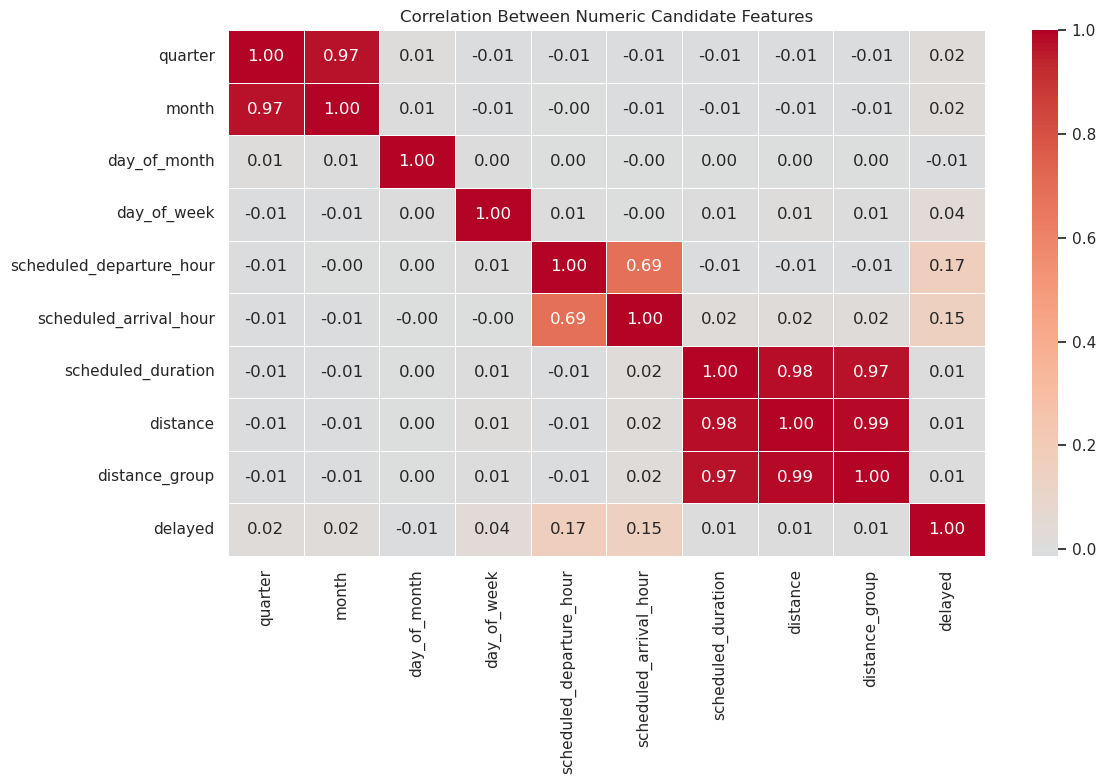

In [23]:
correlation_matrix = numeric_sample.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
	correlation_matrix,
	annot=True,
	fmt=".2f",
	cmap="coolwarm",
	center=0,
	linewidths=0.5
)

plt.title("Correlation Between Numeric Candidate Features")
plt.tight_layout()
plt.show()

In [24]:
airline_delay_rates = wr.athena.read_sql_query(
    f"""
    SELECT
        opuniquecarrier AS airline,
        COUNT(*) AS flights,
        ROUND(
            100.0 * AVG(TRY_CAST(arrdel15 AS DOUBLE)),
            2
        ) AS delay_rate_pct

    FROM {source_table}

    WHERE TRY_CAST(arrdel15 AS DOUBLE) IN (0.0, 1.0)
      AND NULLIF(TRIM(opuniquecarrier), '') IS NOT NULL

    GROUP BY opuniquecarrier
    HAVING COUNT(*) >= 1000
    ORDER BY delay_rate_pct DESC
    """,
    database=athena_db,
    s3_output=athena_s3_output
)

display(airline_delay_rates)

[09/20/26 16:59:28] INFO     Created CTAS table                    ]8;id=14480914;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py\_utils.py]8;;\:]8;id=14480915;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py#928\928]8;;\
                             "aai540_group1"."temp_table_c49ee576e              
                             11549acaeaecc38961067d3"                           


,airline,flights,delay_rate_pct
0,F9,194192,27.91
1,OH,236682,27.53
2,B6,226703,26.15
3,AA,952841,25.71
4,G4,129892,24.97
5,AS,241927,23.10
6,YX,334043,21.51
7,UA,786377,21.47
8,NK,191191,21.41
9,WN,1376837,21.40


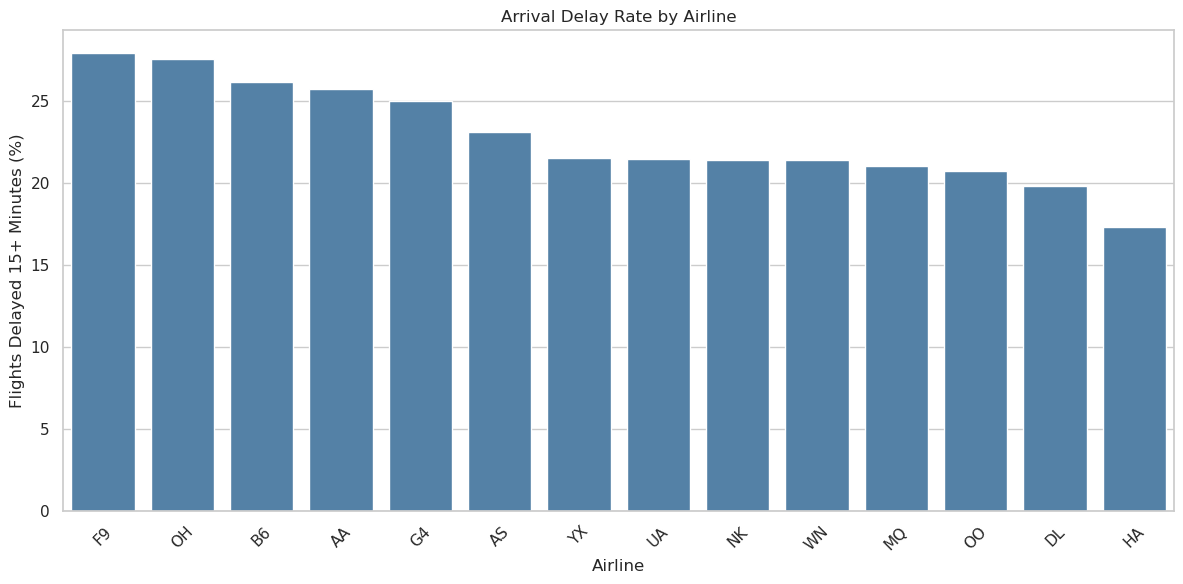

In [25]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=airline_delay_rates,
    x="airline",
    y="delay_rate_pct",
    color="steelblue"
)

plt.title("Arrival Delay Rate by Airline")
plt.xlabel("Airline")
plt.ylabel("Flights Delayed 15+ Minutes (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
hourly_delay_rates = wr.athena.read_sql_query(
    f"""
    SELECT
        MOD(
            CAST(FLOOR(TRY_CAST(crsdeptime AS DOUBLE) / 100) AS INTEGER),
            24
        ) AS scheduled_departure_hour,

        COUNT(*) AS flights,

        ROUND(
            100.0 * AVG(TRY_CAST(arrdel15 AS DOUBLE)),
            2
        ) AS delay_rate_pct

    FROM {source_table}

    WHERE TRY_CAST(arrdel15 AS DOUBLE) IN (0.0, 1.0)
      AND TRY_CAST(crsdeptime AS DOUBLE) IS NOT NULL

    GROUP BY 1
    ORDER BY 1
    """,
    database=athena_db,
    s3_output=athena_s3_output
)

display(hourly_delay_rates)

[09/20/26 16:59:35] INFO     Created CTAS table                    ]8;id=14480920;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py\_utils.py]8;;\:]8;id=14480921;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py#928\928]8;;\
                             "aai540_group1"."temp_table_453f60522              
                             7784abd8ef628e62cb6c49c"                           


,scheduled_departure_hour,flights,delay_rate_pct
0,0,11076,16.55
1,1,3393,17.15
2,2,1299,20.86
3,3,732,17.90
4,4,298,13.42
5,5,194931,8.85
6,6,474704,10.06
7,7,501217,12.73
8,8,478909,14.47
9,9,390739,15.83


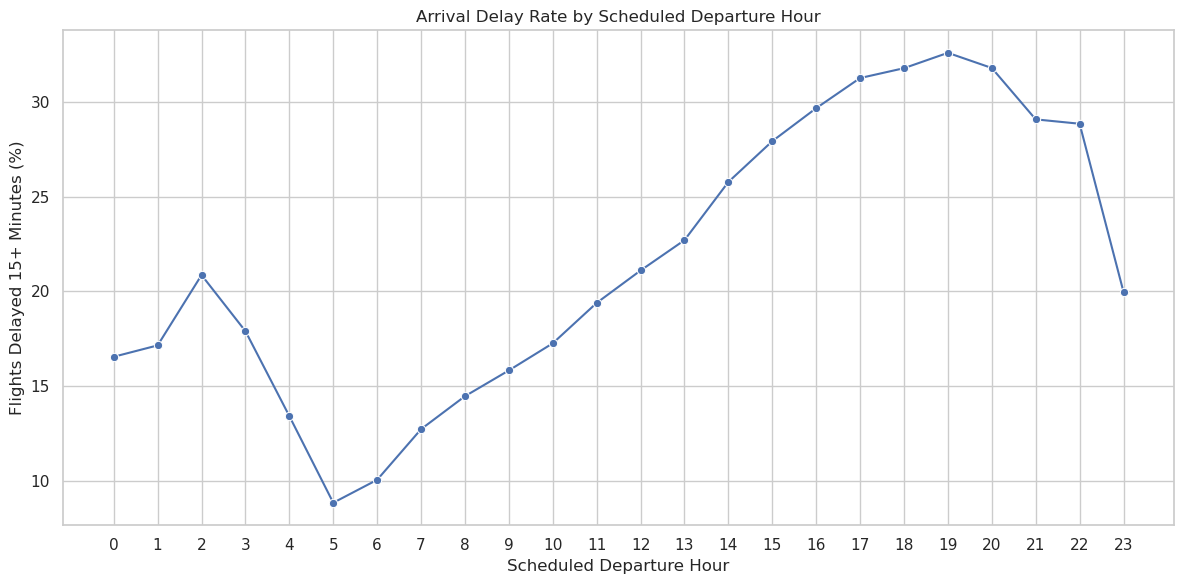

In [27]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_delay_rates,
    x="scheduled_departure_hour",
    y="delay_rate_pct",
    marker="o"
)

plt.title("Arrival Delay Rate by Scheduled Departure Hour")
plt.xlabel("Scheduled Departure Hour")
plt.ylabel("Flights Delayed 15+ Minutes (%)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

### Candidate Feature Findings

The analysis shows that the airline and scheduled time features should be kept. The rate of delays for airlines varied between about 17% and 28%, and the delay rate according to the scheduled departure hour ranged from about 9% in the early morning to over 32% in the evening. There were also the strongest numerical correlations between scheduled departure and arrival times and the target.

Quarter was dropped since it was highly correlated with month and gave less detail. The distance group was removed because it was almost perfectly correlated with distance. Distance and scheduled duration were kept as the initial candidates since they represent route length and planned travel time, respectively, and their final values will be assessed during model validation.


### Feature Engineering

The cleaned data is transformed into model ready features using Athena. Only information available before departure is retained. The engineered dataset is stored as Snappy compressed Parquet in the assigned model ready S3 location.

In [28]:
engineered_table = "flight_delay_features_2025"

table_exists = wr.catalog.does_table_exist(
    database=athena_db,
    table=engineered_table
)

existing_files = wr.s3.list_objects(engineered_s3_path)

if table_exists:
    print(f"SKIP: {athena_db}.{engineered_table} already exists.")

elif existing_files:
    raise RuntimeError(
        f"Files already exist at {engineered_s3_path}, but the Athena "
        "table is missing. Review the location before rerunning."
    )

else:
    feature_query = f"""
    CREATE TABLE {engineered_table}
    WITH (
        format = 'PARQUET',
        parquet_compression = 'SNAPPY',
        external_location = '{engineered_s3_path}'
    ) AS

    WITH prepared AS (
        SELECT
            CAST(
                TRY(
                    date_parse(
                        split_part(TRIM(fldate), ' ', 1),
                        '%c/%e/%Y'
                    )
                ) AS DATE
            ) AS flight_date,

            TRY_CAST(year AS INTEGER) AS flight_year,
            TRY_CAST(month AS INTEGER) AS flight_month,
            TRY_CAST(dayofmonth AS INTEGER) AS day_of_month,
            TRY_CAST(dayofweek AS INTEGER) AS day_of_week,

            NULLIF(TRIM(opuniquecarrier), '') AS airline,
            NULLIF(TRIM(opcarrierflnum), '') AS flight_number,
            NULLIF(TRIM(origin), '') AS origin,
            NULLIF(TRIM(dest), '') AS destination,

            CAST(
                TRY_CAST(crsdeptime AS DOUBLE) AS INTEGER
            ) AS scheduled_departure_hhmm,

            CAST(
                TRY_CAST(crsarrtime AS DOUBLE) AS INTEGER
            ) AS scheduled_arrival_hhmm,

            TRY_CAST(crselapsedtime AS DOUBLE) AS scheduled_duration,
            TRY_CAST(distance AS DOUBLE) AS distance,

            NULLIF(TRIM(deptimeblk), '') AS departure_time_block,
            NULLIF(TRIM(arrtimeblk), '') AS arrival_time_block,

            CAST(
                TRY_CAST(arrdel15 AS DOUBLE) AS INTEGER
            ) AS delayed

        FROM {source_table}
    )

    SELECT
        TO_HEX(
            MD5(
                TO_UTF8(
                    CONCAT(
                        CAST(flight_date AS VARCHAR), '|',
                        airline, '|',
                        flight_number, '|',
                        origin, '|',
                        destination, '|',
                        CAST(scheduled_departure_hhmm AS VARCHAR)
                    )
                )
            )
        ) AS record_id,

        DATE_FORMAT(
            CAST(flight_date AS TIMESTAMP),
            '%Y-%m-%dT%H:%i:%sZ'
        ) AS event_time,

        CAST(flight_date AS VARCHAR) AS flight_date,
        flight_year AS year,
        flight_month AS month,
        day_of_month,
        day_of_week,

        CASE
            WHEN day_of_week IN (6, 7) THEN 1
            ELSE 0
        END AS is_weekend,

        MOD(
            CAST(FLOOR(scheduled_departure_hhmm / 100) AS INTEGER),
            24
        ) AS scheduled_departure_hour,

        MOD(
            CAST(FLOOR(scheduled_arrival_hhmm / 100) AS INTEGER),
            24
        ) AS scheduled_arrival_hour,

        airline,
        flight_number,
        origin,
        destination,
        CONCAT(origin, '-', destination) AS route,

        departure_time_block,
        arrival_time_block,

        scheduled_duration,
        distance,
        delayed

    FROM prepared

    WHERE flight_date IS NOT NULL
      AND flight_month BETWEEN 1 AND 12
      AND day_of_week BETWEEN 1 AND 7
      AND airline IS NOT NULL
      AND flight_number IS NOT NULL
      AND origin IS NOT NULL
      AND destination IS NOT NULL
      AND scheduled_departure_hhmm IS NOT NULL
      AND scheduled_arrival_hhmm IS NOT NULL
      AND scheduled_duration IS NOT NULL
      AND distance IS NOT NULL
      AND delayed IN (0, 1)
    """

    wr.athena.start_query_execution(
        sql=feature_query,
        database=athena_db,
        s3_output=athena_s3_output,
        wait=True
    )

    print("Feature-engineered Parquet table created successfully.")
    print("Table:", f"{athena_db}.{engineered_table}")
    print("Location:", engineered_s3_path)

Feature-engineered Parquet table created successfully.
Table: aai540_group1.flight_delay_features_2025
Location: s3://aai-540-group1-flight-data-processed/model-ready/engineered/


### Engineered Dataset Validation

The engineered dataset is checked before splitting to confirm that records were retained, identifiers are unique, required fields are complete, the target is valid and the table uses Parquet storage.

In [29]:
feature_validation = wr.athena.read_sql_query(
    f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT record_id) AS unique_record_ids,
        COUNT(*) - COUNT(DISTINCT record_id) AS duplicate_record_ids,
        COUNT_IF(record_id IS NULL) AS missing_record_ids,
        COUNT_IF(event_time IS NULL) AS missing_event_times,
        COUNT_IF(month NOT BETWEEN 1 AND 12) AS invalid_months,
        COUNT_IF(delayed NOT IN (0, 1) OR delayed IS NULL) AS invalid_targets,
        ROUND(100.0 * AVG(CAST(delayed AS DOUBLE)), 2) AS delay_rate_pct
    FROM {engineered_table}
    """,
    database=athena_db,
    s3_output=athena_s3_output
)

display(feature_validation)

[09/20/26 17:12:31] INFO     Created CTAS table                    ]8;id=14480926;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py\_utils.py]8;;\:]8;id=14480927;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py#928\928]8;;\
                             "aai540_group1"."temp_table_458aeebbb              
                             09f40358cfc06d934c4be3b"                           


,total_rows,unique_record_ids,duplicate_record_ids,missing_record_ids,missing_event_times,invalid_months,invalid_targets,delay_rate_pct
0,6879484,6879484,0,0,0,0,0,22.31


In [30]:
engineered_months = wr.athena.read_sql_query(
    f"""
    SELECT
        month,
        COUNT(*) AS rows,
        ROUND(100.0 * AVG(CAST(delayed AS DOUBLE)), 2) AS delay_rate_pct
    FROM {engineered_table}
    GROUP BY month
    ORDER BY month
    """,
    database=athena_db,
    s3_output=athena_s3_output
)

display(engineered_months)

[09/20/26 17:13:02] INFO     Created CTAS table                    ]8;id=14480932;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py\_utils.py]8;;\:]8;id=14480933;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py#928\928]8;;\
                             "aai540_group1"."temp_table_be5bfc55c              
                             27b49aaae0cd7deb374947d"                           


,month,rows,delay_rate_pct
0,1,522269,18.79
1,2,496476,20.77
2,3,592301,19.59
3,4,577730,19.66
4,5,597574,23.60
5,6,599472,28.26
6,7,612811,28.89
7,8,593733,22.56
8,9,558328,16.63
9,10,601570,20.32


In [31]:
glue = boto3.client("glue", region_name=region)

table_metadata = glue.get_table(
    DatabaseName=athena_db,
    Name=engineered_table
)["Table"]

storage = table_metadata["StorageDescriptor"]

print("Location:", storage["Location"])
print("Input format:", storage["InputFormat"])
print("Output format:", storage["OutputFormat"])
print("Serialization library:", storage["SerdeInfo"]["SerializationLibrary"])

Location: s3://aai-540-group1-flight-data-processed/model-ready/engineered/
Input format: org.apache.hadoop.hive.ql.io.parquet.MapredParquetInputFormat
Output format: org.apache.hadoop.hive.ql.io.parquet.MapredParquetOutputFormat
Serialization library: org.apache.hadoop.hive.ql.io.parquet.serde.ParquetHiveSerDe


In [32]:
feature_sample = wr.athena.read_sql_query(
    f"""
    SELECT *
    FROM {engineered_table}
    LIMIT 5
    """,
    database=athena_db,
    s3_output=athena_s3_output
)

display(feature_sample)
print("Number of engineered columns:", len(feature_sample.columns))
print(feature_sample.columns.tolist())

[09/20/26 17:13:52] INFO     Created CTAS table                    ]8;id=14480938;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py\_utils.py]8;;\:]8;id=14480939;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py#928\928]8;;\
                             "aai540_group1"."temp_table_a5c49b7b7              
                             77d42e8b4c1b0d9d27a6e21"                           


,record_id,event_time,flight_date,year,month,day_of_month,day_of_week,is_weekend,scheduled_departure_hour,scheduled_arrival_hour,airline,flight_number,origin,destination,route,departure_time_block,arrival_time_block,scheduled_duration,distance,delayed
0,A6189EE28A5628A23394B39BE9770F17,2025-06-10T00:00:00Z,2025-06-10,2025,6,10,2,0,7,9,DL,2045,TPA,SLC,TPA-SLC,0700-0759,0900-0959,276.0,1888.0,1
1,129E091F3E9AD5BD2B80C61F018692E4,2025-06-10T00:00:00Z,2025-06-10,2025,6,10,2,0,12,17,DL,610,DFW,JFK,DFW-JFK,1200-1259,1700-1759,243.0,1391.0,0
2,C0647CCB996BE6D39936F223AEE678E1,2025-06-10T00:00:00Z,2025-06-10,2025,6,10,2,0,7,10,DL,873,LGA,DFW,LGA-DFW,0700-0759,1000-1059,228.0,1389.0,0
3,507CE1F8F374DF3E40A41FE60790BF6D,2025-06-10T00:00:00Z,2025-06-10,2025,6,10,2,0,17,23,DL,905,SLC,ATL,SLC-ATL,1700-1759,2300-2359,229.0,1590.0,0
4,06ABA7818244EF99871CC227045D44EA,2025-06-10T00:00:00Z,2025-06-10,2025,6,10,2,0,17,21,DL,496,JFK,DFW,JFK-DFW,1700-1759,2100-2159,242.0,1391.0,0


Number of engineered columns: 20
['record_id', 'event_time', 'flight_date', 'year', 'month', 'day_of_month', 'day_of_week', 'is_weekend', 'scheduled_departure_hour', 'scheduled_arrival_hour', 'airline', 'flight_number', 'origin', 'destination', 'route', 'departure_time_block', 'arrival_time_block', 'scheduled_duration', 'distance', 'delayed']


## Time-Based Dataset Splitting

The engineered data is split chronologically to prevent future flights from influencing model training. January through May are used for training, June for validation, July for testing and August through December are reserved as production data. Each split is stored as a separate Snappy compressed Parquet dataset.

In [33]:
split_definitions = {
    "training": {
        "table": "flight_delay_train_2025",
        "path": train_s3_path,
        "condition": "month BETWEEN 1 AND 5"
    },
    "validation": {
        "table": "flight_delay_validation_2025",
        "path": validation_s3_path,
        "condition": "month = 6"
    },
    "test": {
        "table": "flight_delay_test_2025",
        "path": test_s3_path,
        "condition": "month = 7"
    },
    "production": {
        "table": "flight_delay_production_2025",
        "path": production_s3_path,
        "condition": "month BETWEEN 8 AND 12"
    }
}

for split_name, config in split_definitions.items():
    split_table = config["table"]
    split_path = config["path"]
    split_condition = config["condition"]

    table_exists = wr.catalog.does_table_exist(
        database=athena_db,
        table=split_table
    )

    existing_files = wr.s3.list_objects(split_path)

    if table_exists:
        print(f"SKIP: {split_table} already exists.")

    elif existing_files:
        raise RuntimeError(
            f"Files already exist at {split_path}, but table "
            f"{split_table} is missing. Review the location."
        )

    else:
        split_query = f"""
        CREATE TABLE {split_table}
        WITH (
            format = 'PARQUET',
            parquet_compression = 'SNAPPY',
            external_location = '{split_path}'
        ) AS
        SELECT *
        FROM {engineered_table}
        WHERE {split_condition}
        """

        wr.athena.start_query_execution(
            sql=split_query,
            database=athena_db,
            s3_output=athena_s3_output,
            wait=True
        )

        print(f"Created {split_name} split:")
        print(f"  Table: {athena_db}.{split_table}")
        print(f"  Path:  {split_path}")

Created training split:
  Table: aai540_group1.flight_delay_train_2025
  Path:  s3://aai-540-group1-flight-data-processed/model-ready/splits/train/
Created validation split:
  Table: aai540_group1.flight_delay_validation_2025
  Path:  s3://aai-540-group1-flight-data-processed/model-ready/splits/validation/
Created test split:
  Table: aai540_group1.flight_delay_test_2025
  Path:  s3://aai-540-group1-flight-data-processed/model-ready/splits/test/
Created production split:
  Table: aai540_group1.flight_delay_production_2025
  Path:  s3://aai-540-group1-flight-data-processed/model-ready/splits/production/


In [34]:
split_summary = wr.athena.read_sql_query(
    """
    SELECT
        'Training' AS dataset,
        COUNT(*) AS rows,
        MIN(month) AS first_month,
        MAX(month) AS last_month,
        ROUND(100.0 * AVG(CAST(delayed AS DOUBLE)), 2) AS delay_rate_pct
    FROM flight_delay_train_2025

    UNION ALL

    SELECT
        'Validation',
        COUNT(*),
        MIN(month),
        MAX(month),
        ROUND(100.0 * AVG(CAST(delayed AS DOUBLE)), 2)
    FROM flight_delay_validation_2025

    UNION ALL

    SELECT
        'Test',
        COUNT(*),
        MIN(month),
        MAX(month),
        ROUND(100.0 * AVG(CAST(delayed AS DOUBLE)), 2)
    FROM flight_delay_test_2025

    UNION ALL

    SELECT
        'Production',
        COUNT(*),
        MIN(month),
        MAX(month),
        ROUND(100.0 * AVG(CAST(delayed AS DOUBLE)), 2)
    FROM flight_delay_production_2025
    """,
    database=athena_db,
    s3_output=athena_s3_output
)

split_total = split_summary["rows"].sum()
split_summary["percentage"] = (
    100.0 * split_summary["rows"] / split_total
).round(2)

split_order = ["Training", "Validation", "Test", "Production"]

split_summary["dataset"] = pd.Categorical(
    split_summary["dataset"],
    categories=split_order,
    ordered=True
)

split_summary = split_summary.sort_values("dataset").reset_index(drop=True)

display(split_summary)
print("Combined rows:", f"{split_total:,}")

[09/20/26 17:19:35] INFO     Created CTAS table                    ]8;id=14480944;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py\_utils.py]8;;\:]8;id=14480945;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py#928\928]8;;\
                             "aai540_group1"."temp_table_f8b893c72              
                             62f4609bcc46e56d3ec5db2"                           


,dataset,rows,first_month,last_month,delay_rate_pct,percentage
0,Training,2786350,1,5,20.53,40.5
1,Validation,599472,6,6,28.26,8.71
2,Test,612811,7,7,28.89,8.91
3,Production,2880851,8,12,21.39,41.88


Combined rows: 6,879,484


In [35]:
split_integrity = wr.athena.read_sql_query(
    """
    WITH combined_splits AS (
        SELECT record_id FROM flight_delay_train_2025
        UNION ALL
        SELECT record_id FROM flight_delay_validation_2025
        UNION ALL
        SELECT record_id FROM flight_delay_test_2025
        UNION ALL
        SELECT record_id FROM flight_delay_production_2025
    )

    SELECT
        COUNT(*) AS total_assignments,
        COUNT(DISTINCT record_id) AS unique_records,
        COUNT(*) - COUNT(DISTINCT record_id) AS overlapping_records
    FROM combined_splits
    """,
    database=athena_db,
    s3_output=athena_s3_output
)

display(split_integrity)

[09/20/26 17:20:03] INFO     Created CTAS table                    ]8;id=14480950;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py\_utils.py]8;;\:]8;id=14480951;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py#928\928]8;;\
                             "aai540_group1"."temp_table_5e328207b              
                             602470db76b00def03e7429"                           


,total_assignments,unique_records,overlapping_records
0,6879484,6879484,0


### Amazon SageMaker Feature Store

An offline SageMaker Feature Store group is created for the engineered flight features. The full engineered and split Parquet datasets remain in the shared team bucket under the assigned model ready prefix. Because SageMaker Feature Store requires additional bucket level permissions for its managed offline store, an account owned S3 bucket is used for the Feature Store data. This avoids changing the shared bucket policy while preserving the chosen data architecture.

In [39]:
feature_store_bucket = (
    f"sagemaker-aai540-feature-store-{account_id}"
)

feature_store_s3_path = (
    f"s3://{feature_store_bucket}/offline-store/"
)

s3_client = boto3.client("s3", region_name=region)

try:
    s3_client.head_bucket(Bucket=feature_store_bucket)
    print("Feature Store bucket already exists.")

except ClientError as error:
    error_code = str(error.response["Error"]["Code"])

    if error_code not in {
        "404",
        "NoSuchBucket",
        "NotFound"
    }:
        raise

    create_arguments = {
        "Bucket": feature_store_bucket
    }

    if region != "us-east-1":
        create_arguments["CreateBucketConfiguration"] = {
            "LocationConstraint": region
        }

    s3_client.create_bucket(**create_arguments)

    s3_client.put_public_access_block(
        Bucket=feature_store_bucket,
        PublicAccessBlockConfiguration={
            "BlockPublicAcls": True,
            "IgnorePublicAcls": True,
            "BlockPublicPolicy": True,
            "RestrictPublicBuckets": True
        }
    )

    s3_client.put_bucket_encryption(
        Bucket=feature_store_bucket,
        ServerSideEncryptionConfiguration={
            "Rules": [
                {
                    "ApplyServerSideEncryptionByDefault": {
                        "SSEAlgorithm": "AES256"
                    }
                }
            ]
        }
    )

    print("Feature Store bucket created successfully.")

print("Feature Store location:", feature_store_s3_path)

Feature Store bucket created successfully.
Feature Store location: s3://sagemaker-aai540-feature-store-697977302576/offline-store/


In [40]:
sagemaker_client = boto3.client("sagemaker", region_name=region)

feature_group_name = "flight-delay-features-2025"
feature_store_table = "flight_delay_feature_store_2025"

feature_definitions = [
    {"FeatureName": "record_id", "FeatureType": "String"},
    {"FeatureName": "event_time", "FeatureType": "String"},
    {"FeatureName": "flight_date", "FeatureType": "String"},

    {"FeatureName": "year", "FeatureType": "Integral"},
    {"FeatureName": "month", "FeatureType": "Integral"},
    {"FeatureName": "day_of_month", "FeatureType": "Integral"},
    {"FeatureName": "day_of_week", "FeatureType": "Integral"},
    {"FeatureName": "is_weekend", "FeatureType": "Integral"},

    {
        "FeatureName": "scheduled_departure_hour",
        "FeatureType": "Integral"
    },
    {
        "FeatureName": "scheduled_arrival_hour",
        "FeatureType": "Integral"
    },

    {"FeatureName": "airline", "FeatureType": "String"},
    {"FeatureName": "flight_number", "FeatureType": "String"},
    {"FeatureName": "origin", "FeatureType": "String"},
    {"FeatureName": "destination", "FeatureType": "String"},
    {"FeatureName": "route", "FeatureType": "String"},

    {
        "FeatureName": "departure_time_block",
        "FeatureType": "String"
    },
    {
        "FeatureName": "arrival_time_block",
        "FeatureType": "String"
    },

    {
        "FeatureName": "scheduled_duration",
        "FeatureType": "Fractional"
    },
    {"FeatureName": "distance", "FeatureType": "Fractional"},
    {"FeatureName": "delayed", "FeatureType": "Integral"}
]

try:
    feature_group_description = sagemaker_client.describe_feature_group(
        FeatureGroupName=feature_group_name
    )

    print("Feature group already exists.")
    print(
        "Status:",
        feature_group_description["FeatureGroupStatus"]
    )

except ClientError as error:
    if error.response["Error"]["Code"] not in {
        "ResourceNotFound",
        "ResourceNotFoundException"
    }:
        raise

    response = sagemaker_client.create_feature_group(
        FeatureGroupName=feature_group_name,
        RecordIdentifierFeatureName="record_id",
        EventTimeFeatureName="event_time",
        FeatureDefinitions=feature_definitions,
        OfflineStoreConfig={
            "S3StorageConfig": {
                "S3Uri": feature_store_s3_path
            },
            "DisableGlueTableCreation": False,
            "DataCatalogConfig": {
                "TableName": feature_store_table,
                "Catalog": "AwsDataCatalog",
                "Database": athena_db
            }
        },
        RoleArn=role_arn,
        Description=(
            "Pre-flight features for predicting whether a flight "
            "will arrive at least 15 minutes late."
        )
    )

    print("Feature group creation started.")
    print("Feature group ARN:", response["FeatureGroupArn"])

Feature group creation started.
Feature group ARN: arn:aws:sagemaker:us-east-1:697977302576:feature-group/flight-delay-features-2025


In [41]:
while True:
    feature_group_description = (
        sagemaker_client.describe_feature_group(
            FeatureGroupName=feature_group_name
        )
    )

    status = feature_group_description["FeatureGroupStatus"]
    print("Feature group status:", status)

    if status == "Created":
        break

    if status in {"CreateFailed", "DeleteFailed"}:
        failure_reason = feature_group_description.get(
            "FailureReason",
            "No failure reason returned."
        )
        raise RuntimeError(failure_reason)

    time.sleep(15)

print("Feature Store group is ready.")

Feature group status: Created
Feature Store group is ready.


### Ingest Features into SageMaker Feature Store

The following steps select a balanced sample from each month, ingest the records into the offline Feature Store and verify the Feature Store configuration.

In [42]:
feature_columns = [
    "record_id",
    "event_time",
    "flight_date",
    "year",
    "month",
    "day_of_month",
    "day_of_week",
    "is_weekend",
    "scheduled_departure_hour",
    "scheduled_arrival_hour",
    "airline",
    "flight_number",
    "origin",
    "destination",
    "route",
    "departure_time_block",
    "arrival_time_block",
    "scheduled_duration",
    "distance",
    "delayed"
]

columns_sql = ", ".join(feature_columns)

feature_store_sample = wr.athena.read_sql_query(
    f"""
    WITH ranked_records AS (
        SELECT
            {columns_sql},
            ROW_NUMBER() OVER (
                PARTITION BY month
                ORDER BY record_id
            ) AS sample_rank
        FROM {engineered_table}
    )
    SELECT {columns_sql}
    FROM ranked_records
    WHERE sample_rank <= 500
    ORDER BY month, record_id
    """,
    database=athena_db,
    s3_output=athena_s3_output
)

display(
    feature_store_sample.groupby("month")
    .size()
    .rename("records")
    .reset_index()
)

print("Records prepared:", len(feature_store_sample))

[09/20/26 17:42:33] INFO     Created CTAS table                    ]8;id=14480956;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py\_utils.py]8;;\:]8;id=14480957;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py#928\928]8;;\
                             "aai540_group1"."temp_table_2b9db3ba3              
                             1c141d2932bb3694b25c2ab"                           


,month,records
0,1,500
1,2,500
2,3,500
3,4,500
4,5,500
5,6,500
6,7,500
7,8,500
8,9,500
9,10,500


Records prepared: 6000


In [43]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from botocore.config import Config

feature_store_runtime = boto3.client(
    "sagemaker-featurestore-runtime",
    region_name=region,
    config=Config(
        retries={
            "max_attempts": 10,
            "mode": "adaptive"
        },
        max_pool_connections=16
    )
)

feature_type_map = {
    definition["FeatureName"]: definition["FeatureType"]
    for definition in feature_definitions
}

def make_feature_store_record(row):
    record = []

    for feature_name in feature_columns:
        value = row[feature_name]

        if pd.isna(value):
            raise ValueError(
                f"Missing value for {feature_name}, record {row['record_id']}"
            )

        feature_type = feature_type_map[feature_name]

        if feature_type == "Integral":
            value_string = str(int(value))
        elif feature_type == "Fractional":
            value_string = str(float(value))
        else:
            value_string = str(value)

        record.append({
            "FeatureName": feature_name,
            "ValueAsString": value_string
        })

    return record

records_to_ingest = feature_store_sample.to_dict("records")

def ingest_record(row):
    feature_store_runtime.put_record(
        FeatureGroupName=feature_group_name,
        Record=make_feature_store_record(row),
        TargetStores=["OfflineStore"]
    )
    return row["record_id"]

successful = 0
failures = []

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {
        executor.submit(ingest_record, row): row["record_id"]
        for row in records_to_ingest
    }

    for future in as_completed(futures):
        record_id = futures[future]

        try:
            future.result()
            successful += 1

            if successful % 500 == 0:
                print(f"Accepted {successful:,} records")

        except Exception as error:
            failures.append((record_id, str(error)))

print("\nFeature Store ingestion requests complete.")
print(f"Successful: {successful:,}")
print(f"Failed:     {len(failures):,}")

if failures:
    display(pd.DataFrame(
        failures[:10],
        columns=["record_id", "error"]
    ))

Accepted 500 records
Accepted 1,000 records
Accepted 1,500 records
Accepted 2,000 records
Accepted 2,500 records
Accepted 3,000 records
Accepted 3,500 records
Accepted 4,000 records
Accepted 4,500 records
Accepted 5,000 records
Accepted 5,500 records
Accepted 6,000 records

Feature Store ingestion requests complete.
Successful: 6,000
Failed:     0


In [44]:
feature_group_description = (
    sagemaker_client.describe_feature_group(
        FeatureGroupName=feature_group_name
    )
)

offline_config = feature_group_description["OfflineStoreConfig"]
catalog_config = offline_config["DataCatalogConfig"]
s3_config = offline_config["S3StorageConfig"]

print("Status:", feature_group_description["FeatureGroupStatus"])
print("Feature group:", feature_group_name)
print("Glue database:", catalog_config["Database"])
print("Glue table:", catalog_config["TableName"])
print(
    "Resolved S3 location:",
    s3_config.get("ResolvedOutputS3Uri", s3_config["S3Uri"])
)

Status: Created
Feature group: flight-delay-features-2025
Glue database: aai540_group1
Glue table: flight_delay_feature_store_2025
Resolved S3 location: s3://sagemaker-aai540-feature-store-697977302576/offline-store/697977302576/sagemaker/us-east-1/offline-store/flight-delay-features-2025-1789925624/data


### Feature Store ingestion strategy

The complete feature engineered dataset of 6,879,484 records is retained in Snappy compressed Parquet in the shared model ready S3 location. The complete training, validation, test and production splits are also stored as Parquet.

A deterministic, month balanced sample of 6,000 records, 500 records from each month, was ingested into the Amazon SageMaker Feature Store offline store. This demonstrates managed feature registration, record identifiers, event time handling, Glue catalog integration and offline feature retrieval without performing millions of individual PutRecord API calls from a notebook.

Production scale ingestion of the complete dataset would use a distributed SageMaker Processing or Spark batch ingestion job.

In [45]:
feature_store_check = wr.athena.read_sql_query(
    f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT record_id) AS unique_records,
        COUNT(DISTINCT month) AS months,
        MIN(month) AS first_month,
        MAX(month) AS last_month
    FROM {feature_store_table}
    """,
    database=athena_db,
    s3_output=athena_s3_output
)

display(feature_store_check)

[09/20/26 17:52:22] INFO     Created CTAS table                    ]8;id=14480962;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py\_utils.py]8;;\:]8;id=14480963;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py#928\928]8;;\
                             "aai540_group1"."temp_table_5e39f99fa              
                             f2442668e12b3b1815bed4a"                           


,total_rows,unique_records,months,first_month,last_month
0,6000,6000,12,1,12


In [46]:
feature_store_monthly_check = wr.athena.read_sql_query(
    f"""
    SELECT
        month,
        COUNT(*) AS records
    FROM {feature_store_table}
    GROUP BY month
    ORDER BY month
    """,
    database=athena_db,
    s3_output=athena_s3_output
)

display(feature_store_monthly_check)

[09/20/26 17:52:45] INFO     Created CTAS table                    ]8;id=14480968;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py\_utils.py]8;;\:]8;id=14480969;file:///opt/conda/lib/python3.12/site-packages/awswrangler/athena/_utils.py#928\928]8;;\
                             "aai540_group1"."temp_table_7235d665a              
                             42740afbc236d96153f10b6"                           


,month,records
0,1,500
1,2,500
2,3,500
3,4,500
4,5,500
5,6,500
6,7,500
7,8,500
8,9,500
9,10,500


### Completion Summary

Feature engineering was completed on the cleaned 2025 flight data and the full dataset was stored as Snappy compressed Parquet. The data was split chronologically into training (40.50%), validation (8.71%), test (8.91%) and production (41.88%) datasets. A balanced sample covering all 12 months was also successfully registered and verified in Amazon SageMaker Feature Store.